In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Customer_Churn_Thesis/'
os.chdir(project_path)
print("Project path:", project_path)

Mounted at /content/drive
Project path: /content/drive/MyDrive/Customer_Churn_Thesis/


In [2]:
DATA_PATH = os.path.join(project_path, "data/processed")
RESULTS_PATH = os.path.join(project_path, "results")

print(project_path)

os.makedirs(f"{RESULTS_PATH}/figures", exist_ok=True)
os.makedirs(f"{RESULTS_PATH}/tables", exist_ok=True)

/content/drive/MyDrive/Customer_Churn_Thesis/


In [3]:
import pandas as pd
import numpy as np

import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score, accuracy_score, roc_auc_score

In [4]:
train = pd.read_csv(f"{DATA_PATH}/train_augmented.csv")
test = pd.read_csv(f"{DATA_PATH}/test_original.csv")

train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Balance_Per_Product,Tenure_Age_Ratio,Is_Senior,Geography_Germany,Geography_Spain,Gender_Male,Exited
0,753,57,7,0.00,1,1,0,159475.08,0.000,0.122807,0,False,False,True,1
1,739,32,3,102128.27,1,1,0,63981.37,102128.270,0.093750,0,True,False,True,1
2,755,37,0,113865.23,2,1,1,117396.25,56932.615,0.000000,0,True,False,False,0
3,561,37,5,0.00,2,1,0,83093.25,0.000,0.135135,0,False,False,True,0
4,692,49,6,110540.43,2,0,1,107472.99,55270.215,0.122449,0,True,False,True,0


In [5]:
TARGET = "Exited"

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

In [6]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6370, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

LGBMClassifier(learning_rate=0.05, max_depth=6, n_estimators=300,
               random_state=42)

In [7]:
probs = model.predict_proba(X_test)[:,1]

In [8]:
COST_FN = 10000   # missed churn customer
COST_FP = 500     # unnecessary retention call

In [9]:
thresholds = np.arange(0.01,0.9,0.01)

costs = []

for t in thresholds:

    preds = (probs > t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    cost = (fn * COST_FN) + (fp * COST_FP)

    costs.append(cost)

In [10]:
best_index = np.argmin(costs)

best_threshold = thresholds[best_index]
best_cost = costs[best_index]

print("Optimal Threshold:", best_threshold)
print("Minimum Cost:", best_cost)

Optimal Threshold: 0.060000000000000005
Minimum Cost: 730500


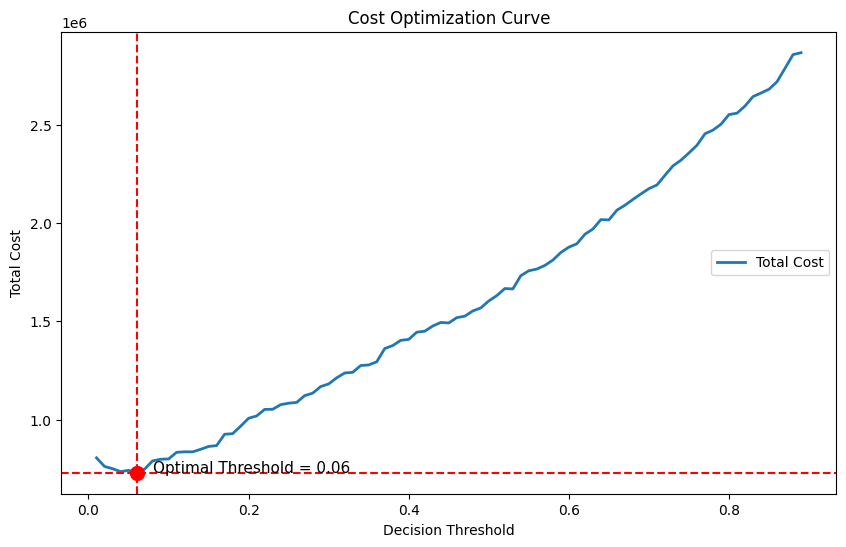

In [11]:
plt.figure(figsize=(10,6))

plt.plot(thresholds, costs, label="Total Cost", linewidth=2)

plt.scatter(best_threshold, best_cost, color="red", s=100, zorder=5)

plt.axvline(best_threshold, color="red", linestyle="--")
plt.axhline(best_cost, color="red", linestyle="--")

plt.text(best_threshold+0.02, best_cost,
         f"Optimal Threshold = {best_threshold:.2f}",
         fontsize=11)

plt.title("Cost Optimization Curve")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Cost")

plt.legend()

plt.savefig(f"{RESULTS_PATH}/figures/05_Cost_Sensitive_Churn_Model_phase2_cost_optimization_curve.png",
            bbox_inches="tight",
            dpi=300)

plt.show()
plt.close()

In [12]:
final_preds = (probs > best_threshold).astype(int)

recall = recall_score(y_test, final_preds)
f1 = f1_score(y_test, final_preds)
precision = precision_score(y_test, final_preds)
roc = roc_auc_score(y_test, probs)
accuracy = accuracy_score(y_test, final_preds)

print("Optimized Recall:", recall)
print("Optimized F1:", f1)
print("Optimized Accuracy:", accuracy)
print("Optimized Precision:", precision)
print("Optimized ROC-AUC:", roc)

Optimized Recall: 0.9484029484029484
Optimized F1: 0.42093784078516905
Optimized Accuracy: 0.469
Optimized Precision: 0.27049754730203224
Optimized ROC-AUC: 0.8445980649370479


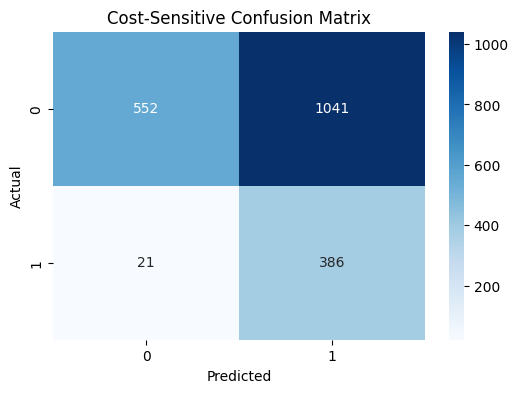

In [13]:
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Cost-Sensitive Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(f"{RESULTS_PATH}/figures/05_Cost_Sensitive_Churn_Model_phase2_Cost_Sensitive_Confusion_Matrix.png")
plt.show()

In [14]:
results = pd.DataFrame({
    "Optimal_Threshold":[best_threshold],
    "Minimum_Cost":[best_cost],
    "Recall":[recall],
    "F1":[f1],
    "Precision":[precision],
    "ROC-AUC":[roc],
    "Accuracy":[accuracy]
})
print(results)
results.to_csv(
    f"{RESULTS_PATH}/tables/05_Cost_Sensitive_Churn_Model_phase2_cost_sensitive_results.csv",
    index=False
)

print("Results saved to Drive")

   Optimal_Threshold  Minimum_Cost    Recall        F1  Precision   ROC-AUC  \
0               0.06        730500  0.948403  0.420938   0.270498  0.844598   

   Accuracy  
0     0.469  
Results saved to Drive
